# Ejemplo práctico: árboles de regresión en Scikit-Learn

Contenido:

1. El problema a resolver
2. Lectura y exploración del set de datos
3. Pre-procesamiento del set de datos
4. Entrenamiento básico del árbol de regresión
5. Entrenamiento y validación del árbol de regresión
6. Prueba y análisis del desempeño del modelo entrenado

## 1. El problema a resolver

El objetivo de esta práctica es entrenar, validar y poner a prueba un árbol de regresión capaz de predecir el precio de renta de una propiedad con base en características como el número de habitaciones, el número de baños y su área entre otros.

## 2. Lectura y exploración del set de datos

Comencemos instalando la versión más actualizada de la librería Scikit-Learn para poder usar algunas funciones que veremos más adelante (la versión mínima requerida para esta práctica es la 1.5.2):

In [1]:
!pip install --upgrade scikit-learn


[notice] A new release of pip available: 22.3.1 -> 24.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
# Verificar que tenemos la versión 1.5.2 (o superior)
import sklearn
print(sklearn.__version__)

1.5.2


Ahora sí realicemos la lectura del set de datos ("alquiler_apartamentos.csv"), que contiene las siguientes columnas:

- "category": uso que se dará al inmueble (vivienda, renta, apartamento)
- "title": información sobre el inmueble publicada en el sitio web de la inmobiliaria
- "body": texto describiendo en detalle las características del inmueble
- "bathrooms": número de baños del inmueble
- "bedrooms": número de habitaciones del inmueble
- "fee": si se debe o no pagar cuota de administración adicional al costo del alquiler
- "pets_allowed": si se permiten o no mascotas y qué tipo de mascotas
- "price_display": costo del alquiler según lo publicado en la página web
- "square_feet": área del inmueble en pies cuadrados

In [3]:
# Leer dataset
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/28-2024-10-ArbolesDeDecision/data/'
df = pd.read_csv(RUTA + 'alquiler_apartamentos.csv')
df

,category,title,body,bathrooms,bedrooms,fee,pets_allowed,price_display,square_feet
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",1.0,1.0,No,Cats,"$2,195",542
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",1.5,3.0,No,"Cats,Dogs","$1,250",1500
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,2.0,3.0,No,None,"$1,395",1650
3,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",1.0,2.0,No,"Cats,Dogs","$1,600",820
4,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",1.0,1.0,No,"Cats,Dogs",$975,624
...,...,...,...,...,...,...,...,...,...
44036,housing/rent/apartment,Live the you've always wanted without compromi...,"At Apartments, our apartment residences are de...",1.0,1.0,No,"Cats,Dogs",$685,625
44037,housing/rent/apartment,"Great Central Location One BR, One BA",nd Park is an upscale apartment community Jack...,1.0,1.0,No,"Cats,Dogs",$798,650
44038,housing/rent/apartment,The Best of the Best in the City of Jacksonvil...,Courtney Manor Apartments offer the best of ev...,2.0,2.0,No,"Cats,Dogs",$813,921
44039,housing/rent/apartment,A great & large One BR apartment. Pet OK!,"Fully remodeled, new floor, kitchen cabinet, s...",1.0,1.0,No,"Cats,Dogs","$1,325",650


Comencemos determinando si el dataset contiene datos faltantes:

In [4]:
# Verificar si hay datos faltantes
df.isna().sum()

category         0
title            0
body             0
bathrooms        0
bedrooms         0
fee              0
pets_allowed     0
price_display    0
square_feet      0
dtype: int64

Los datos están completos. Verifiquemos ahora el tipo de variables que tenemos:

In [5]:
# Determinar tipos de variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44041 entries, 0 to 44040
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       44041 non-null  object 
 1   title          44041 non-null  object 
 2   body           44041 non-null  object 
 3   bathrooms      44041 non-null  float64
 4   bedrooms       44041 non-null  float64
 5   fee            44041 non-null  object 
 6   pets_allowed   44041 non-null  object 
 7   price_display  44041 non-null  object 
 8   square_feet    44041 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 3.0+ MB


Acá vale la pena añadir algunas observaciones importantes:

- Las columnas "category", "title", "body", "fee", "pets_allowed" y "price_display" son columnas categóricas
- Sin embargo la columna "price_display" (el precio del alquiler, la variable a predecir) debería ser numérica

Veamos más en detalle esta última columna:

In [6]:
df['price_display'].value_counts()

$1,350    286
$1,200    260
$950      254
$1,100    249
$1,250    247
         ... 
$4,380      1
$3,828      1
$3,716      1
$2,863      1
$582        1
Name: price_display, Length: 3048, dtype: int64

Vemos que los precios no están indicados como cantidades numéricas sino en formato *string*. En la fase de pre-procesamiento tendremos que convertirlos a representaciones numéricas.

Adicionalmente, todas las demás variables categóricas también tendrán que estar representadas numéricamente puesto que el módulo que usaremos para construir y entrenar el árbol en Scikit-Learn únicamente acepta datos numéricos.

Veamos entonces cómo realizar este pre-procesamiento.

## 3. Pre-procesamiento del set de datos

En esta parte llevaremos a cabo las siguientes fase de pre-procesamiento:

1. Convertiremos la variable "price_display" (variable a predecir) a una representación numérica
2. Eliminaremos columnas irrelevantes (que no contienen información necesaria para construir el modelo y generar predicciones)
3. Representaremos numéricamente las columnas categóricas

Veamos cada una de estas faces, comenzando con la variable "price_display".

Como lo vimos hace un momento los precios están representados como *strings*. Así que debemos eliminar el signo $ y la coma de los precios y convertir el resultado a representación numérica.

Esto lo podemos hacer usando el método "replace" junto con el método "astype". El resultado lo almacenaremos en una nueva columna llamada "price":

In [7]:
# La variable "price_display" (el precio a predecir) debe ser numérica
df['price'] = df['price_display'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df

ValueError: could not convert string to float: '1782 - 1917'

Al intentar ejecutar el código anterior aparece un error porque en algunos casos en lugar de un precio tenemos un rango de precios. Ejemplo: '1782 - 1917'.

Veamos cuántos de estos casos tenemos:

In [8]:
df['price_display'].str.contains('-').value_counts()

False    44013
True        28
Name: price_display, dtype: int64

Tenemos 44013 registros con un precio en formato "normal" (ejemplo: $1,350) y tan sólo 28 registros con un rango de precios. Podemos simplemente eliminar estos 28 registros y luego sí podemos realizar la conversión:

In [9]:
df = df[~df['price_display'].str.contains('-')]

# Y ahora sí podemos realizar la conversión
df['price'] = df['price_display'].replace({'\$': '', ',': ''}, regex=True).astype(float)
df

/var/folders/1m/9cqrfyd50y187jzs__s4l9b80000gn/T/ipykernel_14801/2039352061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price_display'].replace({'\$': '', ',': ''}, regex=True).astype(float)


,category,title,body,bathrooms,bedrooms,fee,pets_allowed,price_display,square_feet,price
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",1.0,1.0,No,Cats,"$2,195",542,2195.0
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",1.5,3.0,No,"Cats,Dogs","$1,250",1500,1250.0
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,2.0,3.0,No,None,"$1,395",1650,1395.0
3,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",1.0,2.0,No,"Cats,Dogs","$1,600",820,1600.0
4,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",1.0,1.0,No,"Cats,Dogs",$975,624,975.0
...,...,...,...,...,...,...,...,...,...,...
44036,housing/rent/apartment,Live the you've always wanted without compromi...,"At Apartments, our apartment residences are de...",1.0,1.0,No,"Cats,Dogs",$685,625,685.0
44037,housing/rent/apartment,"Great Central Location One BR, One BA",nd Park is an upscale apartment community Jack...,1.0,1.0,No,"Cats,Dogs",$798,650,798.0
44038,housing/rent/apartment,The Best of the Best in the City of Jacksonvil...,Courtney Manor Apartments offer the best of ev...,2.0,2.0,No,"Cats,Dogs",$813,921,813.0
44039,housing/rent/apartment,A great & large One BR apartment. Pet OK!,"Fully remodeled, new floor, kitchen cabinet, s...",1.0,1.0,No,"Cats,Dogs","$1,325",650,1325.0


En este punto ya tenemos en el formato correcto la columna correspondiente al precio. Así que podemos eliminar la columna "price_display".

Adicionalmente podemos eliminar las columnas "title" y "body" que no contienen información relevante para el árbol que entrenaremos más adelante:

In [10]:
# Las columnas "title" y "body" son irrelevantes en este caso y pueden ser eliminadas
# así como "price_display"
df.drop(columns=['title', 'body', 'price_display'], inplace=True)
df

/var/folders/1m/9cqrfyd50y187jzs__s4l9b80000gn/T/ipykernel_14801/2930850509.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['title', 'body', 'price_display'], inplace=True)


,category,bathrooms,bedrooms,fee,pets_allowed,square_feet,price
0,housing/rent/apartment,1.0,1.0,No,Cats,542,2195.0
1,housing/rent/apartment,1.5,3.0,No,"Cats,Dogs",1500,1250.0
2,housing/rent/apartment,2.0,3.0,No,None,1650,1395.0
3,housing/rent/apartment,1.0,2.0,No,"Cats,Dogs",820,1600.0
4,housing/rent/apartment,1.0,1.0,No,"Cats,Dogs",624,975.0
...,...,...,...,...,...,...,...
44036,housing/rent/apartment,1.0,1.0,No,"Cats,Dogs",625,685.0
44037,housing/rent/apartment,1.0,1.0,No,"Cats,Dogs",650,798.0
44038,housing/rent/apartment,2.0,2.0,No,"Cats,Dogs",921,813.0
44039,housing/rent/apartment,1.0,1.0,No,"Cats,Dogs",650,1325.0


Veamos el comportamiento de las columnas categóricas restantes ("category", "fee", "pets_allowed"). Si alguna de estas variables contiene un sólo nivel también podremos eliminarla pues no contiene información relevante:

In [11]:
# Analicemos las variables categoricas
cols_cat = ['category', 'fee', 'pets_allowed']
for col in cols_cat:
    print(df[col].value_counts())
    print('-'*25)

housing/rent/apartment    44013
Name: category, dtype: int64
-------------------------
No     43943
Yes       70
Name: fee, dtype: int64
-------------------------
Cats,Dogs    37021
None          5026
Cats          1839
Dogs           127
Name: pets_allowed, dtype: int64
-------------------------


En efecto la columna "category" contiene un único nivel ("housing/rent/apartment") y por tanto podemos eliminarla sin riesgo de perder información:

In [12]:
# La columna "category" contiene sólo una categoría, así que puede ser eliminada
df.drop(columns=['category'], inplace=True)
df

/var/folders/1m/9cqrfyd50y187jzs__s4l9b80000gn/T/ipykernel_14801/245816457.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['category'], inplace=True)


,bathrooms,bedrooms,fee,pets_allowed,square_feet,price
0,1.0,1.0,No,Cats,542,2195.0
1,1.5,3.0,No,"Cats,Dogs",1500,1250.0
2,2.0,3.0,No,None,1650,1395.0
3,1.0,2.0,No,"Cats,Dogs",820,1600.0
4,1.0,1.0,No,"Cats,Dogs",624,975.0
...,...,...,...,...,...,...
44036,1.0,1.0,No,"Cats,Dogs",625,685.0
44037,1.0,1.0,No,"Cats,Dogs",650,798.0
44038,2.0,2.0,No,"Cats,Dogs",921,813.0
44039,1.0,1.0,No,"Cats,Dogs",650,1325.0


¡Perfecto! Ahora sólo nos resta codificar numéricamente las variables categóricas. En este las variables son "fee" (con niveles "Yes" y "No") y "pets_allowed" (con niveles )

¡Perfecto! Ahora sólo nos resta codificar numéricamente las variables categóricas. En este las variables son "fee" (con niveles "Yes" y "No") y "pets_allowed" (con niveles "Cats,Dogs", "None", "Cats" y "Dogs").

Como son variables categóricas **nominales** no podemos usar, por ejemplo, codificación ordinal (como lo hicimos en el caso del árbol de clasificación).

Así que en este caso usaremos la codificación one hot. Por ejemplo, para la variable "fee" la codificación sería:

- Yes -> [1, 0]
- No -> [0, 1]

y para la variable "pets_allowed" las codificaciones serían:

- "Cats,Dogs" -> [1, 0, 0, 0]
- "None" -> [0, 1, 0, 0]
- "Cats" -> [0, 0, 1, 0]
- "Dogs" -> [0, 0, 0, 1]

Y esta codificación se puede implementar en una sóla línea de código usando el método "get_dummies()" de Pandas:

In [13]:
# Las columnas categóricas restantes (fee y pets_allowed) serán codificadas
# en formato one-hot
df = pd.get_dummies(df)
df

,bathrooms,bedrooms,square_feet,price,fee_No,fee_Yes,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_None
0,1.0,1.0,542,2195.0,1,0,1,0,0,0
1,1.5,3.0,1500,1250.0,1,0,0,1,0,0
2,2.0,3.0,1650,1395.0,1,0,0,0,0,1
3,1.0,2.0,820,1600.0,1,0,0,1,0,0
4,1.0,1.0,624,975.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
44036,1.0,1.0,625,685.0,1,0,0,1,0,0
44037,1.0,1.0,650,798.0,1,0,0,1,0,0
44038,2.0,2.0,921,813.0,1,0,0,1,0,0
44039,1.0,1.0,650,1325.0,1,0,0,1,0,0


Muy bien, en este punto ya tenemos casi listo nuestro set de datos. Simplemente reorganicemos las columnas para que la columna a predecir ("price") sea la última columna:

In [14]:
# Reordenamiento de las columnas (para dejar "price" como última columna)
df = df[['bathrooms', 'bedrooms', 'square_feet', 'fee_No', 'fee_Yes',
       'pets_allowed_Cats', 'pets_allowed_Cats,Dogs', 'pets_allowed_Dogs',
       'pets_allowed_None', 'price']]
df

,bathrooms,bedrooms,square_feet,fee_No,fee_Yes,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_None,price
0,1.0,1.0,542,1,0,1,0,0,0,2195.0
1,1.5,3.0,1500,1,0,0,1,0,0,1250.0
2,2.0,3.0,1650,1,0,0,0,0,1,1395.0
3,1.0,2.0,820,1,0,0,1,0,0,1600.0
4,1.0,1.0,624,1,0,0,1,0,0,975.0
...,...,...,...,...,...,...,...,...,...,...
44036,1.0,1.0,625,1,0,0,1,0,0,685.0
44037,1.0,1.0,650,1,0,0,1,0,0,798.0
44038,2.0,2.0,921,1,0,0,1,0,0,813.0
44039,1.0,1.0,650,1,0,0,1,0,0,1325.0


Ahora sí podemos crear los sets de datos para entrenamiento/validación y para prueba. Para ello usaremos "train_test_split" de Scikit-Learn para generar las dos particiones (el set de prueba contendrá el 25%) de los datos:

In [15]:
from sklearn.model_selection import train_test_split

# Arreglos x y y
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Creación sets de entrenamiento/validación y prueba
x_trvl, x_ts, y_trvl, y_ts = train_test_split(x, y, 
                                          test_size=0.25, # Tamaño del set de prueba: 25% del total 
                                          random_state=123, # Para reproducibilidad
                                          )

# Imprimir en pantalla los tamaños de los sets que acabamos de crear
print('Tamaño set de entrenamiento/validación: ', x_trvl.shape, y_trvl.shape)
print('Tamaño set de prueba: ', x_ts.shape, y_ts.shape)

Tamaño set de entrenamiento/validación:  (33009, 9) (33009,)
Tamaño set de prueba:  (11004, 9) (11004,)


¡Y listo, ya estamos listos para ver cómo crear y entrenar un Árbol de Regresión!

## 4. Entrenamiento básico del árbol de regresión

La creación y entrenamiento de un árbol de regresión en Scikit-Learn sigue la misma lógica que vimos anteriormente para el caso del árbol de clasificación:

1. Primero creamos una instancia del árbol de regresión
2. Y luego lo entrenamos usando el método "fit"

Veamos cómo hacer esto:

In [16]:
# Entrenamiento básico del regresor
from sklearn.tree import DecisionTreeRegressor

# Crear instancia del clasificador y entrenar con el set de entrenamiento/validación (x_trvl, y_trvl)
arbol = DecisionTreeRegressor()
arbol.fit(x_trvl, y_trvl)

DecisionTreeRegressor()

Y listo, es así de simple.

Al igual que con los árboles de clasificación, podemos usar "plot_tree" del módulo "tree" para generar un gráfico del árbol:

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Tamaño de la figura
tree.plot_tree(arbol,
               feature_names=x_trvl.columns, # Para que contenga los nombres de las características
               class_names = [y_trvl.name], # Para que contenga los nombres de las categorías
               filled=True,  # Colorear las hojas
               rounded=True, # Bordes redondeados
               );

Error in callback <function flush_figures at 0x16aa4ff60> (for post_execute):


KeyboardInterrupt: 

En el caso anterior el tiempo requerido para generar el gráfico puede ser muy extenso. Esto se debe a que tenemos un árbol de regresión inmenso (pues estamos usando los parámetros por defecto definidos por Scikit-Learn).

Esto lo podemos verificar imprimiendo en pantalla la profundidad del árbol:

In [18]:
# Características del árbol
print(f'Profundidad del árbol: {arbol.get_depth()}')
print(f'Parámetros usados en el entrenamiento: {arbol.get_params()}')

Profundidad del árbol: 37
Parámetros usados en el entrenamiento: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


¡Se trata de un árbol de profundidad 37! y es por esto que la generación del gráfico toma tanto tiempo.

Entrenemos un árbol mucho más pequeño, por ejemplo definiendo una profundidad máxima (parámetro "max_depth") de 5:

Profundidad del árbol: 5


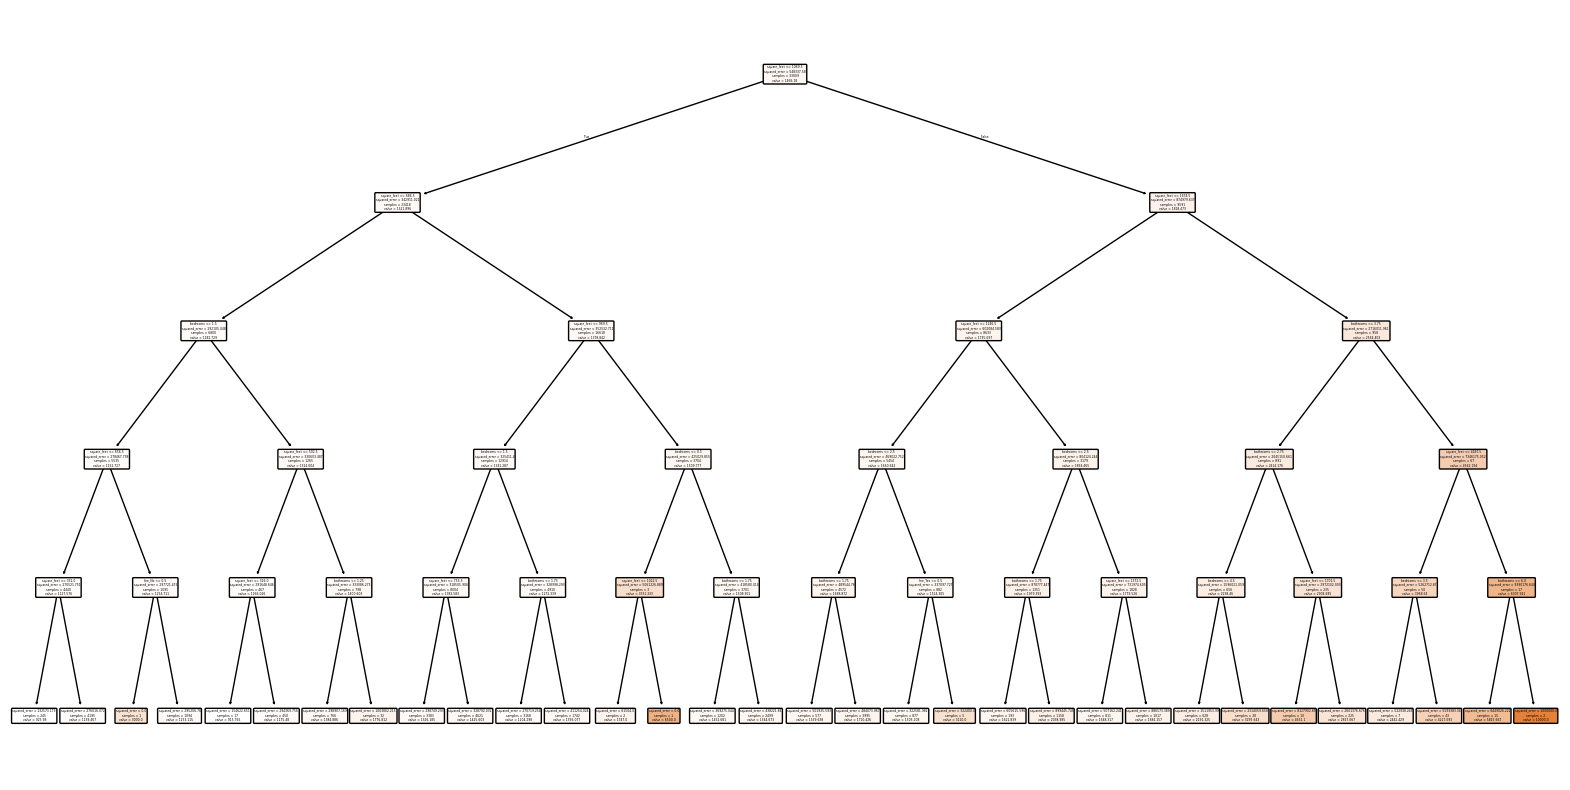

In [19]:
# Reentrenar pero con una profundidad máxima de 5
arbol = DecisionTreeRegressor(max_depth=5,
                               random_state=123)
arbol.fit(x_trvl,y_trvl)

# Graficar
plt.figure(figsize=(20, 10))
tree.plot_tree(arbol,
               feature_names=x_trvl.columns, # Para que contenga los nombres de las características
               class_names = [y_trvl.name], # Para que contenga los nombres de las categorías
               filled=True,  # Colorear las hojas
               rounded=True, # Bordes redondeados
               );
print(f'Profundidad del árbol: {arbol.get_depth()}')

# Guardar el árbol como archivo PNG de alta resolución
plt.savefig('arbol_regresion.png', dpi=300)

Y en este punto ya hemos visto la forma básica de entrenar un árbol de regresión.

Veamos ahora cómo realizar su validación usando, nuevamente, *k-fold cross-validation*.

## 5. Entrenamiento y validación del árbol de regresión

Usaremos la misma lógica de entrenamiento y validación usada en el ejercicio del árbol de clasificación: *k-fold cross-validation*.

Sin embargo, en este caso modificaremos la métrica para medir el desempeño del modelo. Por defecto para los árboles de regresión Scikit-Learn usa el **coeficiente de determinación de la predicción**:

> The coefficient of determination $R^2$ is defined as $(1-\frac{u}{v})$, where $u$ is the residual sum of squares ((y_true - y_pred)** 2).sum() and $v$ is the total sum of squares ((y_true - y_true.mean()) ** 2).sum(). The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a score of 0.0.

En este caso usaremos una métrica que resulta más fácil de interpretar que es la raíz cuadrada del error cuadrático medio (o RMSE por sus siglas en Inglés):

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left( y_{\text{true},i} - y_{\text{pred},i} \right)^2}$$

donde $N$ es el número total de predicciones, y "y_true" y "y_pred" son los valores reales y las predicciones generadas por el modelo.

Esta métrica resulta más adecuada pues sus unidades son las mismas de la variable a predecir (que en este caso es el precio de renta del inmueble).

Como Scikit-Learn no tiene implementada directamente esta función haremos lo siguiente:

- Durante la validación cruzada usaremos la métrica "neg_mean_squared_error" que permite calcular el error cuadrático medio negativo
- Multiplicaremos por -1 el resultado anterior para obtener el error cuadrático medio
- Y a este error cuadrático medio le calcularemos la raíz cuadrada para obtener el RMSE

Veamos esta implementación:

In [20]:
# Entrenamiento y validación con k-fold
from sklearn.model_selection import cross_val_score
import numpy as np

# Crear modelo
arbol = DecisionTreeRegressor(random_state=123)

# Realizar validación cruzada (k-fold cross-validation) con k=5
scores = np.sqrt(-1*cross_val_score(arbol, x_trvl, y_trvl, cv=5, scoring='neg_mean_squared_error'))

# Imprimir resultados validación cruzada
print("Puntajes validación cruzada:", scores)
print("Promedio puntajes (RMSE):", scores.mean())
print("Desviación puntajes (RMSE):", scores.std())

Puntajes validación cruzada: [782.097592   748.5357549  766.06335996 776.44175299 729.21339866]
Promedio puntajes (RMSE): 760.4703716989345
Desviación puntajes (RMSE): 19.35735848530511


Lo anterior quiere decir que en promedio las predicciones se alejan 760.47 dólares del valor real del alquiler del inmueble.

Veamos cómo funciona un modelo menos complejo, con una profundidad de 5:

In [21]:
# Crear modelo con profundidad de 5

arbol = DecisionTreeRegressor(random_state=123, max_depth=5)

# Realizar validación cruzada (k-fold cross-validation) con k=5
scores = np.sqrt(-1*cross_val_score(arbol, x_trvl, y_trvl, cv=5, scoring='neg_mean_squared_error'))

# Imprimir resultados validación cruzada
print("Puntajes validación cruzada:", scores)
print("Promedio puntajes (RMSE):", scores.mean())
print("Desviación puntajes (RMSE):", scores.std())

Puntajes validación cruzada: [711.82138889 672.00103625 670.97638679 673.33551158 662.38290287]
Promedio puntajes (RMSE): 678.1034452749752
Desviación puntajes (RMSE): 17.29047555897449


En este caso el modelo es capaz de **generalizar** mejor, pues su error promedio (RMSE) es menor que para el árbol con profundidad de 37. En este caso en promedio cada predicción se aleja 678.1 dólares del valor real del alquiler del inmueble.

Habiendo completado esta validación lo único que nos resta es entrenar el modelo con la totalidad del set de entrenamiento/validación:

In [22]:
# Árbol final
arbol = DecisionTreeRegressor(max_depth=5,
                               random_state=123)
arbol.fit(x_trvl,y_trvl)

DecisionTreeRegressor(max_depth=5, random_state=123)

## 6. Prueba y análisis del desempeño del modelo entrenado

En este punto lo único que nos falta es poner a prueba el modelo y evaluar su desempeño. Para ello:

- Generaremos predicciones con datos nuevos, es decir con los datos de prueba
- Analizaremos el desempeño del modelo entrenado, calculando el RMSE de las predicciones tanto con los datos de entrenamiento/validación como con los de prueba

Para generar las predicciones simplemente usaremos el método "predict" asociado al árbol que acabamos de entrenar:

In [23]:
# Predicciones sobre el set de prueba
y_pred = arbol.predict(x_ts)
print(y_pred)

[2191.32484076 1204.29829545 1539.63778163 ... 1544.67346939 1139.46650775
 4217.09302326]


Cada uno de los valores corresponde precisamente a los precios predichos por el modelo para los inmuebles que se encontraban en el set de prueba.

Veamos ahora cómo realizar la validación. Para ello:

1. Generaremos predicciones con el set de entrenamiento usando el método "predict"
2. Calcularemos el puntaje (o métrica de desempeño) usando el método "score"
3. Repetiremos los pasos anteriores para el set de prueba

Por defecto el "score" calculado será el índice $R^2$:

In [24]:
# Puntaje con entrenamiento y prueba

# Entrenamiento
#y_pred = arbol.predict(x_trvl)
score = arbol.score(x_trvl, y_trvl)
print("R² score entrenamiento:", score)

# Prueba
#y_pred = arbol.predict(x_ts)
score = arbol.score(x_ts, y_ts)
print("R² score prueba:", score)

R² score entrenamiento: 0.19415379199483995
R² score prueba: 0.22208733578100426


Para interpretar mejor los resultados, calculemos el desempeño usando el RMSE en lugar del puntaje $R^2$:

In [25]:
# RMSE entrenamiento y prueba
from sklearn.metrics import root_mean_squared_error

# Entrenamiento
y_pred = arbol.predict(x_trvl)
rmse = root_mean_squared_error(y_trvl, y_pred)
print("RMSE entrenamiento: ", rmse)

# Prueba
y_pred = arbol.predict(x_ts)
rmse = root_mean_squared_error(y_ts, y_pred)
print("RMSE prueba: ", rmse)

RMSE entrenamiento:  664.7373613751953
RMSE prueba:  718.7070335376145


Y en este punto podemos decir que:

- Al usar el set de entrenamiento el modelo comete un error RMSE promedio de 664.8 dólares al momento de predecir el valor de los alquileres
- Y al usar el set de prueba este error RMSE promedio es de 718.7 dólares

Lo anterior quiere decir que el modelo tiene algo de "sobreajuste" (*overfitting*) funciona mejor con el set de entrenamiento pero el desempeño es inferior con el set de prueba.

Más adelante veremos cómo usar estrategias para intentar reducir este *overfitting* y mejorar así la capacidad de generalización del modelo.